<a href="https://colab.research.google.com/github/23f1002879/Pytorch-Computer-Vision/blob/master/notebooks/04_Model_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
transform = transforms.ToTensor()

trainDataset = datasets.FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=transform
)

testDataset = datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 212kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.93MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 22.5MB/s]


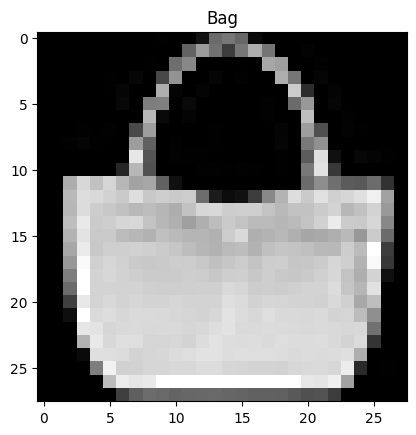

In [4]:
classes = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

image, label = trainDataset[100]

plt.imshow(image.squeeze(), cmap="gray")
plt.title(classes[label])
plt.show()

In [5]:
trainLoader = DataLoader(
    trainDataset,
    batch_size=32,
    shuffle=True
)

testLoader = DataLoader(
    testDataset,
    batch_size=32,
    shuffle=False
)

In [6]:
class CNN(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(
        in_channels=1,
        out_channels=32,
        kernel_size=3,
        padding=1
    )

    self.conv2 = nn.Conv2d(
        in_channels=32,
        out_channels=128,
        kernel_size=3,
        padding=2
    )

    self.relu = nn.ReLU()

    self.pool = nn.MaxPool2d(2)

    self.fc1 = nn.Linear(
        in_features=128*15*15,
        out_features=128
    )

    self.fc2 = nn.Linear(
        in_features=128,
        out_features=10
    )

  def forward(self, x):
    x = self.conv1(x)

    x = self.relu(x)

    x = self.conv2(x)

    x = self.relu(x)

    x = self.pool(x)

    x = x.view(x.size(0),-1)

    x = self.fc1(x)

    x = self.relu(x)

    x = self.fc2(x)

    return x



In [7]:
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [8]:
epoch = int(input("Enter the number of epochs: "))

trainLoss = []

for i in range(epoch):
  running_loss=0
  model.train()

  for images, labels in trainLoader:
    images = images.to(device)
    labels = labels.to(device)
    output = model(images)
    loss = criterion(output, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    running_loss += loss.item()

  trainLoss.append(running_loss/len(trainLoader))
  print(f"Epoch {i+1}/{epoch} Loss: {running_loss/len(trainLoader)}")


Enter the number of epochs: 5
Epoch 1/5 Loss: 0.3719495049794515
Epoch 2/5 Loss: 0.22475700526734194
Epoch 3/5 Loss: 0.16865035123402874
Epoch 4/5 Loss: 0.1263523472510278
Epoch 5/5 Loss: 0.09262334221241375


In [9]:
# Evaluating the model

model.eval()

total = 0
correct = 0
all_preds = []
all_labels = []

with torch.no_grad():
  for images, labels in testLoader:
    images = images.to(device)
    labels = labels.to(device)
    output = model(images)
    _, pred = torch.max(output, 1)
    total += labels.size(0)
    correct += (pred == labels).sum().item()
    all_preds.extend(pred.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

print(f"Accuracy: {100*correct/total}")

Accuracy: 92.07


In [10]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

print(cm)


[[859   0  18  26   1   2  89   0   5   0]
 [  2 977   0  13   2   0   5   0   1   0]
 [ 13   1 870  10  52   0  54   0   0   0]
 [ 12   2  12 930  27   0  17   0   0   0]
 [  1   0  59  20 860   0  60   0   0   0]
 [  0   0   1   0   0 985   0   6   0   8]
 [ 88   0  51  26  36   0 791   0   8   0]
 [  0   0   0   0   0   5   0 978   0  17]
 [  2   0   1   4   2   2   5   2 982   0]
 [  0   0   0   0   0   3   1  21   0 975]]


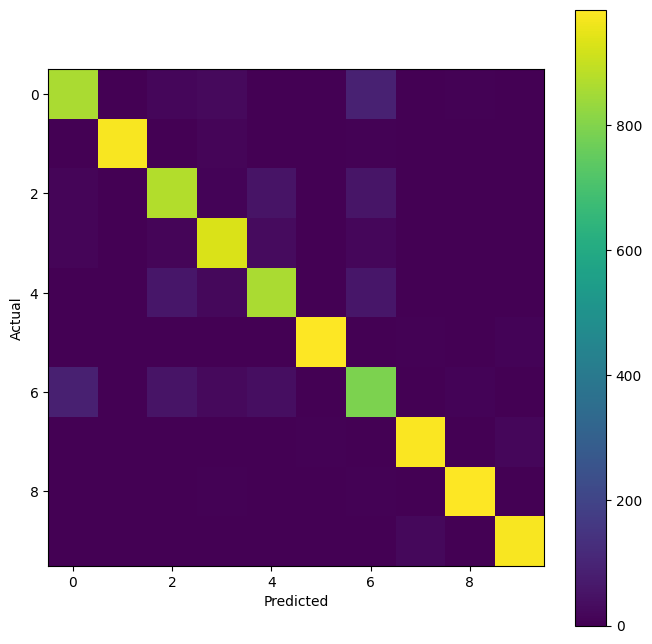

In [11]:
plt.figure(figsize=(8,8))

plt.imshow(cm)

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


In [12]:
print(
    classification_report(
        all_labels,
        all_preds
    )
)



              precision    recall  f1-score   support

           0       0.88      0.86      0.87      1000
           1       1.00      0.98      0.99      1000
           2       0.86      0.87      0.86      1000
           3       0.90      0.93      0.92      1000
           4       0.88      0.86      0.87      1000
           5       0.99      0.98      0.99      1000
           6       0.77      0.79      0.78      1000
           7       0.97      0.98      0.97      1000
           8       0.99      0.98      0.98      1000
           9       0.97      0.97      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000

